# This notebook shows how to compute effective masses from the k·p sum rule
### Import the necessary libraries

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure

### The k·p sum rule
Second-order perturbation theory in $\mathbf{k}$ gives the band curvature as a sum over the other bands,
$$ \left(\frac{1}{m^*}\right)^{ab}_n = \delta_{ab} + 2\sum_{m\neq n} \frac{\mathrm{Re}\left[p^a_{nm}p^b_{mn}\right]}{\varepsilon_n-\varepsilon_m} $$
with $p^a_{nm}$ the momentum matrix elements. Each term pushes band $n$ away from band $m$: intermediate states *below* raise the curvature, states *above* lower it.

In [2]:
SI_AVEC = [(5.13, 5.13, 0.00), (5.13, 0.00, 5.13), (0.00, 5.13, 5.13)]
SI_SPECIES = {"Si": [(0.0, 0.0, 0.0), (0.25, 0.25, 0.25)]}

si = Structure(SI_AVEC, SI_SPECIES).get_calculation(
    "_scratch/si_effmass_kp", xc="PW", ngridk=(4, 4, 4), rgkmax=7.0,
    extra_blocks={"nempty": [40]},  # the sum runs over these; see the convergence plot
)
si.get_energy()

-578.0727918148

### Convergence: the denominator's *first* power is the whole story
Unlike the quantum-geometric sums (which carry $\Delta\varepsilon^2$), this one decays only as $\Delta\varepsilon$, so it converges markedly more slowly. Every omitted state lies *above* band $n$, so each omitted term is negative and the truncated value must approach its limit **from above** — a direction, not just a bound.

In [3]:
K, BAND = (0.0, 0.0, 0.0), 1
# nstates truncates the sum in Python -- identical to a smaller nempty (to 1e-11),
# so the whole sweep comes from ONE ground state instead of one run per point
retained = [4, 8, 12, 20, 30, 40, 60, 85]
inv_mass = [si.get_effective_mass_sum_rule(K, BAND, nstates=n)["inverse_mass"][0, 0]
            for n in retained]

# the independent reference: Elk task 25, a polynomial fit to eigenvalues.
# Its "derivative_tensor" is the raw d2E/dk2, i.e. 1/m* directly
ref = si.get_effective_mass(K)
ref_inv = next(s for s in ref if s["state"] == BAND)["derivative_tensor"][0, 0]
inv_mass[-1], ref_inv

(np.float64(0.8876350325759732), np.float64(0.861086671))

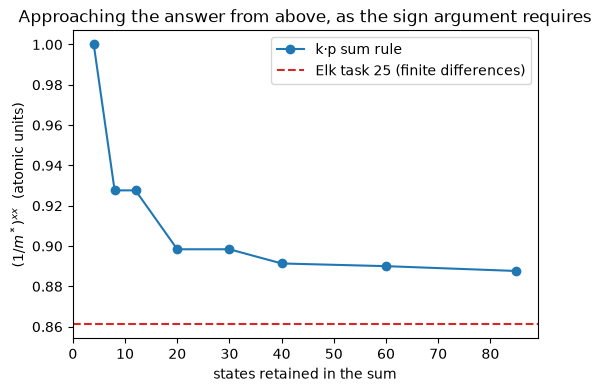

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(retained, inv_mass, "o-", label="k·p sum rule")
ax.axhline(ref_inv, color="C3", ls="--", label="Elk task 25 (finite differences)")
ax.set_xlabel("states retained in the sum")
ax.set_ylabel(r"$(1/m^*)^{xx}$  (atomic units)")
ax.set_title("Approaching the answer from above, as the sign argument requires")
ax.legend()
plt.show()

### Which bands make the mass
The sum rule is resolved by intermediate band, which a finite-difference mass cannot be. Band 1 is the lowest state here, so every other band lies above it and every contribution is negative — which is the same fact that forces the convergence above to approach from one side. A handful of nearby bands dominate; the rest of the manifold contributes little each, but enough in total that the sum is still drifting at 85 states.

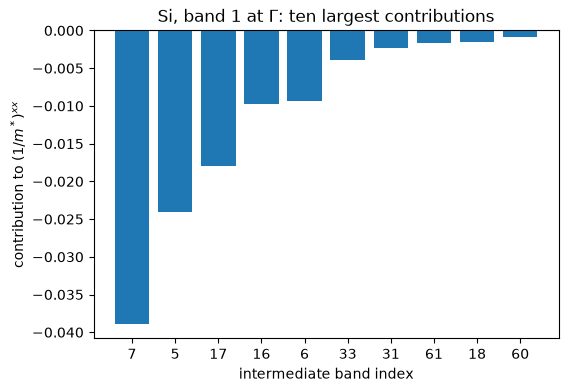

In [5]:
d = si.get_effective_mass_sum_rule(K, BAND, decompose=True)
contrib = d["contributions"][:, 0, 0]  # xx component, per intermediate band
top = np.argsort(-np.abs(contrib))[:10]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(i + 1) for i in top], contrib[top],
       color=["C0" if c < 0 else "C3" for c in contrib[top]])
ax.axhline(0, color="0.6", lw=0.8)
ax.set_xlabel("intermediate band index")
ax.set_ylabel(r"contribution to $(1/m^*)^{xx}$")
ax.set_title("Si, band 1 at $\\Gamma$: ten largest contributions")
plt.show()